In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
!pip install transformers tqdm

import pandas as pd
from transformers import pipeline
from tqdm import tqdm


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


/Users/tiarasabrina/Documents/PROJECT/AI/sentiment_icdsg/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [3]:
df = pd.read_csv('/content/drive/MyDrive/TA DATA PREPROCESSING/HASIL EKSTRAKSI/newdata_merged_fix.csv')
df = df.dropna(subset=['translated_text', 'final_text'])

NameError: name 'pd' is not defined

**MODEL DETEKSI EMOSI (Pre-trained)**

In [ ]:
print("Sedang memuat model pelabelan otomatis...")
classifier = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base", return_all_scores=False)

Sedang memuat model pelabelan otomatis...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Device set to use cpu
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


**PROSES PELABELAN (Looping)**

In [ ]:
print("Sedang melabeli data...")

def get_emotion(text):
    try:
        pred = classifier(text[:512])[0]
        return pred['label']
    except:
        return "neutral"

tqdm.pandas()
df['label_emotion'] = df['translated_text'].progress_apply(get_emotion)

Sedang melabeli data...


100%|██████████| 168003/168003 [3:05:32<00:00, 15.09it/s]


**SIMPAN HASILNYA**

In [ ]:
df.to_csv('/content/drive/MyDrive/TA DATA PREPROCESSING/Crawling Ulang/DATA_FINAL_WITH_EMOTION.csv', index=False)

print("Selesai! kolom 'label_emotion' ditambahkan.")
print(df[['final_text', 'label_emotion']].head())
print(df['label_emotion'].value_counts())

Selesai! kolom 'label_emotion' ditambahkan.
                                          final_text label_emotion
0          dumah dah kaya hutan bakar penuh asap weh         anger
1  bakar hah sampe asap gitu kayak bakar hutan ji...         anger
2             manado penuh asap kayak br bakar hutan         anger
3  indonesia bebas bakar hutan polusi lingkung jd...       neutral
4                rapi kayak abis bakar hutan tsunami          fear
label_emotion
anger       78644
neutral     40385
fear        23098
sadness     11207
disgust      9223
surprise     2729
joy          2717
Name: count, dtype: int64


**Fasttext + SVM**

In [ ]:
!pip install gensim

In [ ]:
import pandas as pd
import numpy as np
from gensim.models import FastText
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/TA DATA PREPROCESSING/Crawling Ulang/DATA_FINAL_WITH_EMOTION.csv')

print("Jumlah data awal:", len(df))
print("Sebaran awal:", df['label_emotion'].value_counts())

Jumlah data awal: 168003
Sebaran awal: label_emotion
anger       78644
neutral     40385
fear        23098
sadness     11207
disgust      9223
surprise     2729
joy          2717
Name: count, dtype: int64


**FILTER HANYA 3 EMOSI**

In [ ]:
target_emotions = ['joy', 'sadness', 'anger']
df = df[df['label_emotion'].isin(target_emotions)].copy()

**UBAH NAMA LABEL KE INDONESIA**

In [ ]:
map_emosi = {
    'joy': 'Senang',
    'sadness': 'Sedih',
    'anger': 'Marah'
}
df['label_emotion'] = df['label_emotion'].map(map_emosi)

print("\nJumlah data setelah filter:", len(df))
print("Sebaran setelah filter:\n", df['label_emotion'].value_counts())


Jumlah data setelah filter: 92568
Sebaran setelah filter:
 label_emotion
Marah     78644
Sedih     11207
Senang     2717
Name: count, dtype: int64


**PENYEIMBANGAN DATA (UNDERSAMPLING)**

In [ ]:
print("\n--- PROSES PENYEIMBANGAN DATA ---")

# 1. Cek jumlah data paling sedikit (Minority Class)
min_count = df['label_emotion'].value_counts().min()
print(f"Jumlah data terkecil (Senang): {min_count}")

# 2. Ambil sampel dari masing-masing kelas sebanyak min_count
df_marah = df[df['label_emotion'] == 'Marah'].sample(n=min_count, random_state=42)
df_sedih = df[df['label_emotion'] == 'Sedih'].sample(n=min_count, random_state=42)
df_senang = df[df['label_emotion'] == 'Senang'].sample(n=min_count, random_state=42)

# 3. Gabungkan kembali
df_balanced = pd.concat([df_marah, df_sedih, df_senang])

# 4. Acak urutannya biar tidak berurutan per kelas
df = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nSebaran Data Setelah Balancing:")
print(df['label_emotion'].value_counts())
print(f"Total Data Baru: {len(df)}")
print("-----------------------------------")


--- PROSES PENYEIMBANGAN DATA ---
Jumlah data terkecil (Senang): 2717

Sebaran Data Setelah Balancing:
label_emotion
Senang    2717
Marah     2717
Sedih     2717
Name: count, dtype: int64
Total Data Baru: 8151
-----------------------------------


/tmp/ipython-input-1192574643.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[nama_kolom_tanggal] = pd.to_datetime(df[nama_kolom_tanggal], errors='coerce')



=== Total Data per Tahun ===
tahun
2010      97
2011     391
2012     928
2013     650
2014    1028
2015    1811
2016     134
2017      84
2018     136
2019    1964
2020     816
2023      59
2025      53
Name: count, dtype: int64

=== Tabel Silang: Emosi vs Tahun ===
label_emotion  Marah  Sedih  Senang
tahun                              
2010              24     35      38
2011             103    138     150
2012             340    324     264
2013             236    198     216
2014             434    362     232
2015             754    720     337
2016              61     58      15
2017              12     30      42
2018              22     28      86
2019             531    582     851
2020             182    213     421
2023               9     12      38
2025               9     17      27


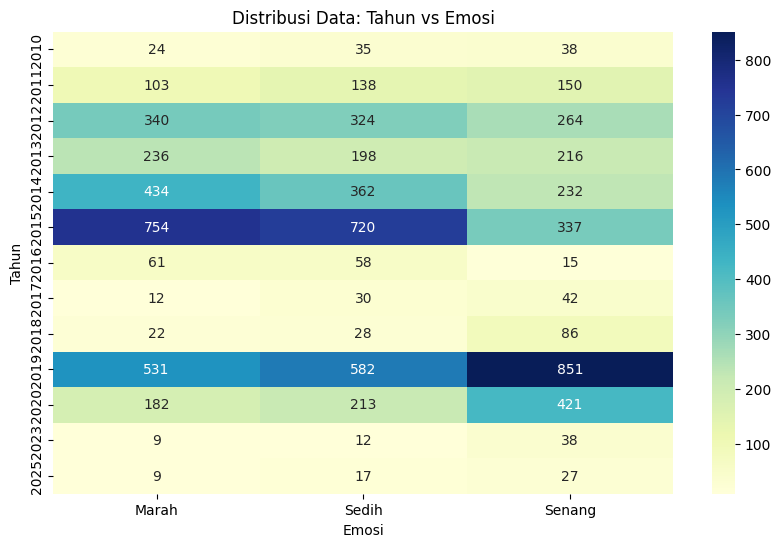

In [ ]:
# ==========================================================
# CEK SEBARAN TAHUN SETELAH BALANCING
# ==========================================================

# 1. Tentukan nama kolom tanggal (Sesuaikan dengan data kamu)
# Biasanya 'created_at' atau 'timestamp' atau 'date'
nama_kolom_tanggal = 'created_at'  # <--- GANTI INI JIKA ERROR

# Cek apakah kolom ada
if nama_kolom_tanggal in df.columns:
    # Konversi ke format datetime agar bisa diambil tahunnya
    df[nama_kolom_tanggal] = pd.to_datetime(df[nama_kolom_tanggal], errors='coerce')

    # Buat kolom baru 'tahun'
    df['tahun'] = df[nama_kolom_tanggal].dt.year

    # 2. Lihat jumlah data per tahun secara global
    print("\n=== Total Data per Tahun ===")
    print(df['tahun'].value_counts().sort_index())

    # 3. Lihat penyebaran Emosi di setiap Tahun (INI YANG PALING PENTING)
    print("\n=== Tabel Silang: Emosi vs Tahun ===")
    crosstab = pd.crosstab(df['tahun'], df['label_emotion'])
    print(crosstab)

    # 4. Visualisasi biar enak dilihat
    plt.figure(figsize=(10, 6))
    sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlGnBu')
    plt.title('Distribusi Data: Tahun vs Emosi')
    plt.ylabel('Tahun')
    plt.xlabel('Emosi')
    plt.show()

else:
    print(f"Kolom '{nama_kolom_tanggal}' tidak ditemukan. Coba cek df.columns")

In [ ]:
sentences = [str(text).split() for text in df['final_text']]
y = df['label_emotion']

**TRAINING FASTTEXT (FEATURE EXTRACTION)**

In [ ]:
print("\nSedang melatih FastText...")
# vector_size=100 adalah standar
ft_model = FastText(sentences, vector_size=100, window=5, min_count=1, workers=4, epochs=10)

# Fungsi Mengubah Kalimat jadi Vektor (Rata-rata vektor kata)
def text_to_vector(text_list, model):
    vectors = [model.wv[word] for word in text_list if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

# Terapkan vektorisasi ke semua data (Inilah representasi FastText)
X = np.array([text_to_vector(kalimat, ft_model) for kalimat in sentences])

print(f"Shape X (Fitur): {X.shape}")
print(f"Shape y (Label): {y.shape}")


Sedang melatih FastText...
Shape X (Fitur): (8151, 100)
Shape y (Label): (8151,)


**Normalisasi Fitur (Scaling)**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Normalisasi Fitur (Angka vektor diubah ke range 0-1)
scaler = MinMaxScaler()
X = scaler.fit_transform(X) # X sekarang sudah dinormalisasi

**SPLIT DATA (80% Latih, 20% Uji)**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

**TRAINING SVM (DENGAN GRID SEARCH)**

In [ ]:
print("\nSedang mencari parameter SVM terbaik...")

# Skenario pengujian parameter SVM
param_grid = {
    'C': [1, 10, 100],            # Parameter Regularisasi
    'kernel': ['rbf', 'linear'],  # Jenis Kernel
    'gamma': ['scale', 'auto']    # Kernel Coefficient
}

svm = SVC()
grid_search = GridSearchCV(svm, param_grid, cv=5, verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)


Sedang mencari parameter SVM terbaik...
Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [1, 10, 100], 'gamma': ['scale', 'auto'],
                         'kernel': ['rbf', 'linear']},
             verbose=2)

**HASIL & EVALUASI**

In [ ]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n" + "="*40)
print(f"Akurasi Terbaik: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Parameter Terbaik: {grid_search.best_params_}")
print("="*40)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Akurasi Terbaik: 66.52%
Parameter Terbaik: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}

Classification Report:
              precision    recall  f1-score   support

       Marah       0.67      0.69      0.68       543
       Sedih       0.73      0.50      0.59       544
      Senang       0.63      0.81      0.71       544

    accuracy                           0.67      1631
   macro avg       0.68      0.67      0.66      1631
weighted avg       0.68      0.67      0.66      1631



**VISUALISASI CONFUSION MATRIX**

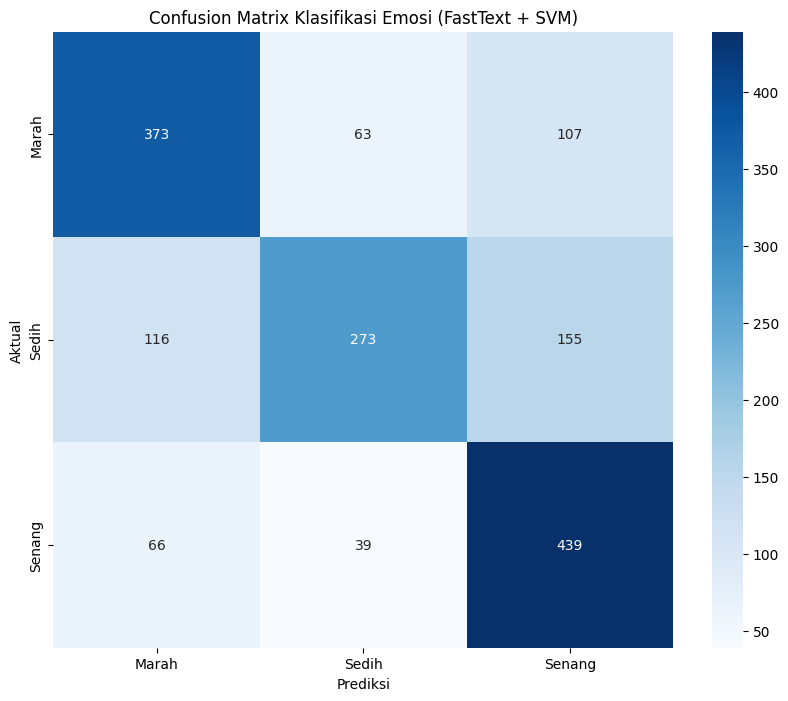

In [ ]:
plt.figure(figsize=(10,8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_model.classes_,
            yticklabels=best_model.classes_)
plt.title('Confusion Matrix Klasifikasi Emosi (FastText + SVM)')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()

**PERCOBAAN KE-2**

**TRAINING FASTTEXT**

In [ ]:
import time
print("\n[1/3] Melatih FastText (Dimensi 300, Epoch 30)...")
start_ft = time.time()

# Upgrade: vector_size=300, epochs=30
ft_model = FastText(sentences, vector_size=300, window=5, min_count=1, workers=4, epochs=30)

def text_to_vector(text_list, model):
    vectors = [model.wv[word] for word in text_list if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

X = np.array([text_to_vector(kalimat, ft_model) for kalimat in sentences])


[1/3] Melatih FastText (Dimensi 300, Epoch 30)...


**SCALING DATA**

In [ ]:
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

print(f"FastText Selesai: {time.time()-start_ft:.2f} detik")

FastText Selesai: 28.17 detik


**TRAINING SVM (GRID SEARCH)**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n[2/3] Grid Search SVM (Fokus RBF)...")
# Parameter Fokus (RBF saja biar cepat tapi akurat)
param_grid = {
    'C': [10, 50, 100, 200],
    'kernel': ['rbf'],
    'gamma': ['scale', 0.1, 1, 10]
}

svm = SVC()
grid_search = GridSearchCV(svm, param_grid, cv=3, verbose=2, n_jobs=-1) # verbose=2 biar kelihatan jalan

start_svm = time.time()
grid_search.fit(X_train, y_train)
print(f"SVM Selesai: {(time.time()-start_svm)/60:.2f} menit")


[2/3] Grid Search SVM (Fokus RBF)...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
SVM Selesai: 4.33 menit


**EVALUASI**

In [ ]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n" + "="*40)
print(f"Akurasi Akhir: {accuracy_score(y_test, y_pred)*100:.2f}%")
    print(f"Parameter Juara: {grid_search.best_params_}")
    print("="*40)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


Akurasi Akhir: 71.61%
Parameter Juara: {'C': 50, 'gamma': 0.1, 'kernel': 'rbf'}

Classification Report:
              precision    recall  f1-score   support

       Marah       0.74      0.71      0.73       543
       Sedih       0.72      0.64      0.68       544
      Senang       0.69      0.80      0.74       544

    accuracy                           0.72      1631
   macro avg       0.72      0.72      0.71      1631
weighted avg       0.72      0.72      0.71      1631



**Confusion Matrix**

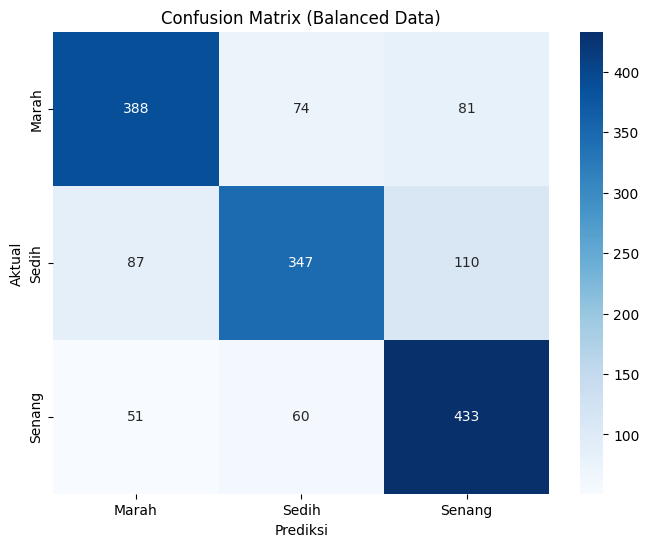

In [ ]:
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_model.classes_,
            yticklabels=best_model.classes_)
plt.title('Confusion Matrix (Balanced Data)')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()

**PERCOBAAN KE-3**

**LOAD FULL DATA (UNTUK MELATIH FASTTEXT)**

In [ ]:
path_file = '/content/drive/MyDrive/TA DATA PREPROCESSING/Crawling Ulang/DATA_FINAL_WITH_EMOTION.csv'
df_full = pd.read_csv(path_file)
df_full = df_full.dropna(subset=['final_text'])
sentences_full = [str(text).split() for text in df_full['final_text']]

print(f"Melatih FastText dengan {len(sentences_full)} kalimat (Full Data)...")

Melatih FastText dengan 168003 kalimat (Full Data)...


**TRAIN FASTTEXT**

In [ ]:
start_ft = time.time()
ft_model_full = FastText(sentences_full, vector_size=300, window=5, min_count=2, workers=4, epochs=20)
print(f"FastText Full Training Selesai: {time.time()-start_ft:.2f} detik")

FastText Full Training Selesai: 252.97 detik


**DATA BALANCING**

In [ ]:
target_emotions = ['joy', 'sadness', 'anger']
df_labeled = df_full[df_full['label_emotion'].isin(target_emotions)].copy()
map_emosi = {'joy': 'Senang', 'sadness': 'Sedih', 'anger': 'Marah'}
df_labeled['label_emotion'] = df_labeled['label_emotion'].map(map_emosi)

In [ ]:
min_count = df_labeled['label_emotion'].value_counts().min()
df_marah = df_labeled[df_labeled['label_emotion'] == 'Marah'].sample(n=min_count, random_state=42)
df_sedih = df_labeled[df_labeled['label_emotion'] == 'Sedih'].sample(n=min_count, random_state=42)
df_senang = df_labeled[df_labeled['label_emotion'] == 'Senang'].sample(n=min_count, random_state=42)

df_final = pd.concat([df_marah, df_sedih, df_senang])
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nData untuk SVM (Balanced): {len(df_final)} baris")


Data untuk SVM (Balanced): 8151 baris


**VEKTORISASI**

In [ ]:
sentences_svm = [str(text).split() for text in df_final['final_text']]
y = df_final['label_emotion']

def text_to_vector(text_list, model):
    vectors = [model.wv[word] for word in text_list if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

X = np.array([text_to_vector(kalimat, ft_model_full) for kalimat in sentences_svm])

**SCALING**

In [ ]:
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

**TRAINING SVM**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

param_grid = {
    'C': [50, 100],
    'kernel': ['rbf'],
    'gamma': [0.1, 'scale']
}

print("\nRunning SVM Final...")
svm = SVC()
grid_search = GridSearchCV(svm, param_grid, cv=5, verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)


Running SVM Final...
Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [50, 100], 'gamma': [0.1, 'scale'],
                         'kernel': ['rbf']},
             verbose=2)

**EVALUASI**

In [ ]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n" + "="*40)
print(f"Akurasi Percobaan Full Data: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("="*40)
print(classification_report(y_test, y_pred))


Akurasi Percobaan Full Data: 73.08%
              precision    recall  f1-score   support

       Marah       0.73      0.72      0.72       543
       Sedih       0.72      0.71      0.72       544
      Senang       0.74      0.76      0.75       544

    accuracy                           0.73      1631
   macro avg       0.73      0.73      0.73      1631
weighted avg       0.73      0.73      0.73      1631



**CONFUSION MATRIX**

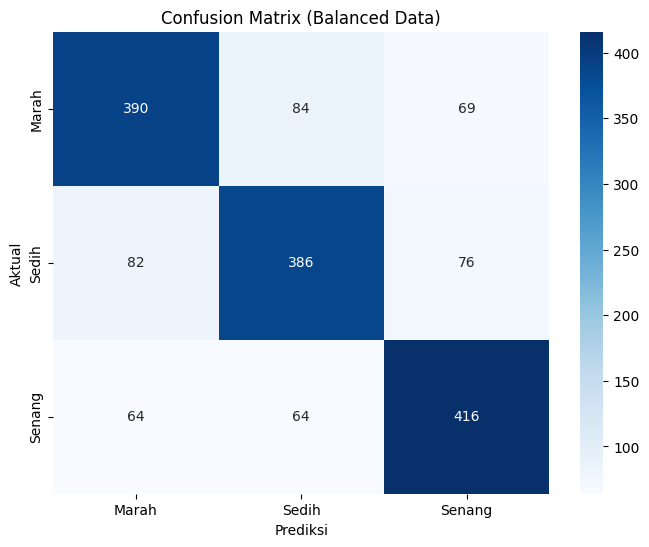

In [ ]:
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_model.classes_,
            yticklabels=best_model.classes_)
plt.title('Confusion Matrix (Balanced Data)')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()